# **Aprendizaje supervizado**: Clasificación

# Máquina de Soporte Vectorial (SVM)
La clasificación supervizada con SVM consiste en encontrar el **hiperplano óptimo** que separa *dos clases* en el espacio de variables, maximizando el **margen** entre ellas. Los puntos más cercanos al hiperplano se denominan **vectores soporte** y definen la frontera de decisión.

Aunque SVM fue diseñado originalmente para **clasificación binaria**, puede extenderse a problemas multiclase mediante estrategias como:
- One-vs-One (OVO): compara cada par de clases.
- One-vs-Rest (OVR): compara cada clase contra todas las demás.

🎯 El objetivo de este notebook es poner en práctica la teoría de SVM sobre datasets reales. Para ello vamos a aplicar diferentes kernels, observar los parámetros que podemos varaiar y como afectan a la frontera de decisión.

# Librerías Necesarias

In [ ]:
import os

# Análisis exploratorio
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pylab as pl

# Preparación de los datos
from sklearn.model_selection import train_test_split, GridSearchCV, validation_curve
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn import datasets

# Clasificador SVM
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay ,classification_report)
import warnings
warnings.filterwarnings('ignore')

# Dataset: Análisis de casos de infarto de miocardio

https://www.kaggle.com/datasets/rashikrahmanpritom/heart-attack-analysis-prediction-dataset/data

### Atributos
* Age: edad del peciente (años)
* Sex: sexo del paciente (M: Masculino, F: Femenino)
* ChestPainType: tipo de dolor en el pecho:
  * TA: Angina típica
  * ATA: Angina atípica
  * NAP: Dolor no aginal
  * ASY: Asintomático
* RestingBP: presión arterial en reposo (mmHg)
* Cholesterol: colesterol sérico (mm/dl)
* FastingBS: glucemia en ayunas:
  * 1: si FastingBS > 120 mg/dl
  * 0: si no
* RestingECG: resultados del electrocardiograma en reposo:
  * Normal: Normal
  * ST: tener anomalía de la onda ST-T (inversiones de la onda T y/o elevación o depresión del ST > 0,05 mV)
  * LVH: que muestra hipertrofia ventricular izquierda probable o definitiva según los criterios de Estes
* MaxHR: frecuencia cardíaca máxima alcanzada (valor numérico entre 60 y 202)
* ExerciseAngina: angina inducida por el ejercicio (Y: Si, N: No)
* Oldpeak: pico previo.
* ST_Slope: la pendiente del segmento ST del ejercicio máximo:
  * Up: upsloping
  * Flat: flat
  * Down: downsloping
* target :
  * 0: menos posibilidades de sufrir un ataque cardíaco
  * 1: más posibilidades de sufrir un ataque cardíaco

In [ ]:
!gdown 1Q00pSYZdljWCf3eQ_oS8I2AHGsl2y_1C

Downloading...
From: https://drive.google.com/uc?id=1Q00pSYZdljWCf3eQ_oS8I2AHGsl2y_1C
To: /content/heart.csv
100% 35.9k/35.9k [00:00<00:00, 68.2MB/s]


In [ ]:
df = pd.read_csv("heart.csv")

# Estructura

In [ ]:
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [ ]:
# Obtener información general sobre el DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
# Obtener estadísticas descriptivas
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [ ]:
df["HeartDisease"].value_counts()

,count
HeartDisease,
1,508
0,410


# División train-test

In [ ]:
# Separo variable objetivo de datos
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

In [ ]:
# Obtengo datos de entrenamiento y de testeo
Xtrn, Xtst, ytrn, ytst  = train_test_split(X, y, test_size=0.2,
                            random_state=1234, shuffle=True, stratify=y)

# Análisis exploratorio

## Correlación de variables

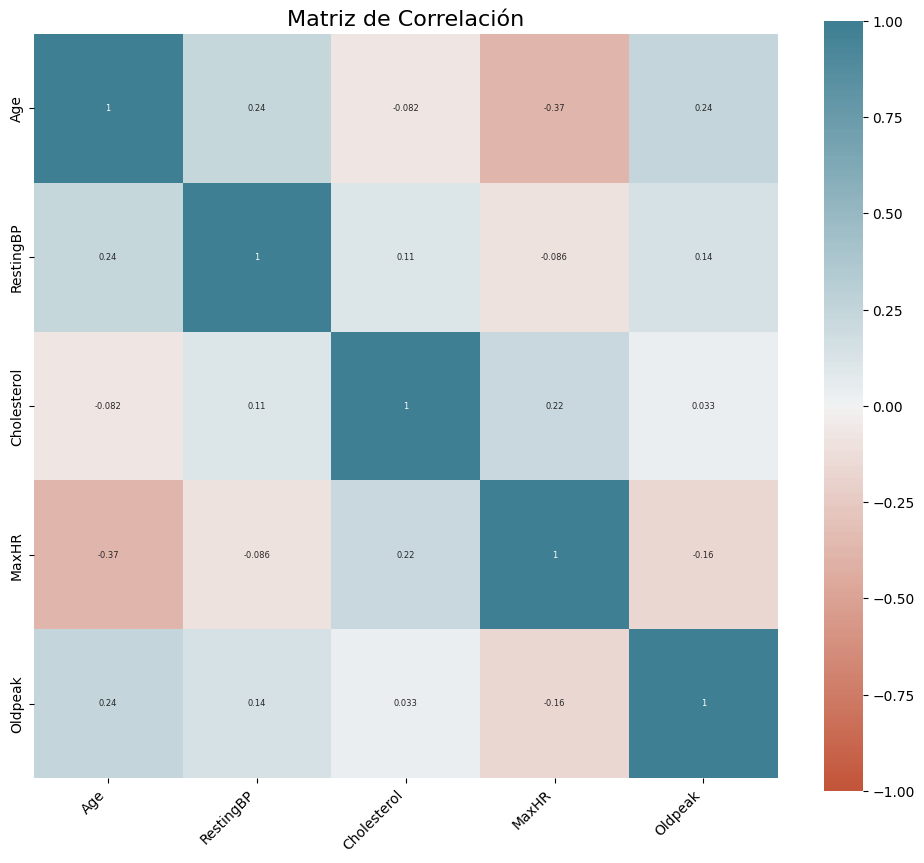

In [ ]:
num_cols = df.columns[[0, 3, 4, 7, 9]]
plt.figure(figsize=(12, 10))
corr = Xtrn[num_cols].corr(method='pearson')
ax = sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True,
    annot = True,
    annot_kws = {'size': 6}
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
)
plt.title('Matriz de Correlación', fontsize=16)
plt.show()

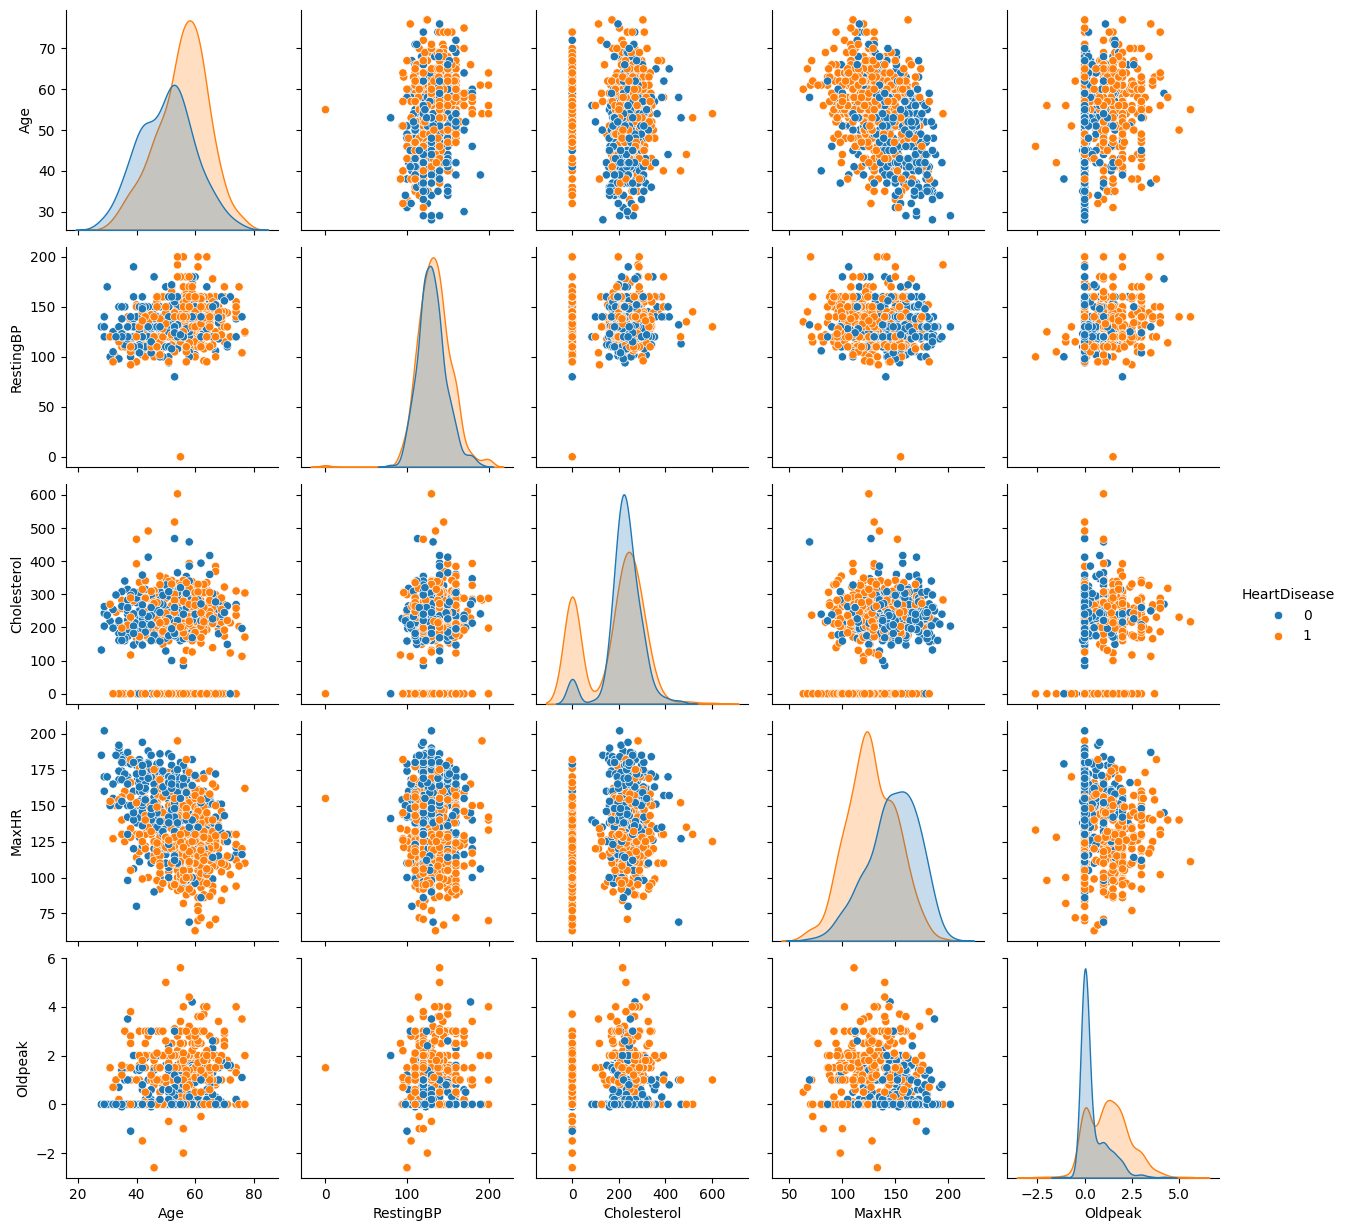

In [ ]:
sns.pairplot(pd.concat([Xtrn[num_cols], ytrn], axis=1), hue='HeartDisease')
plt.show()

In [ ]:
clean_idx = ~(Xtrn[num_cols]==0).any(axis=1)
Xtrn = Xtrn.loc[clean_idx]
ytrn = ytrn.loc[clean_idx]

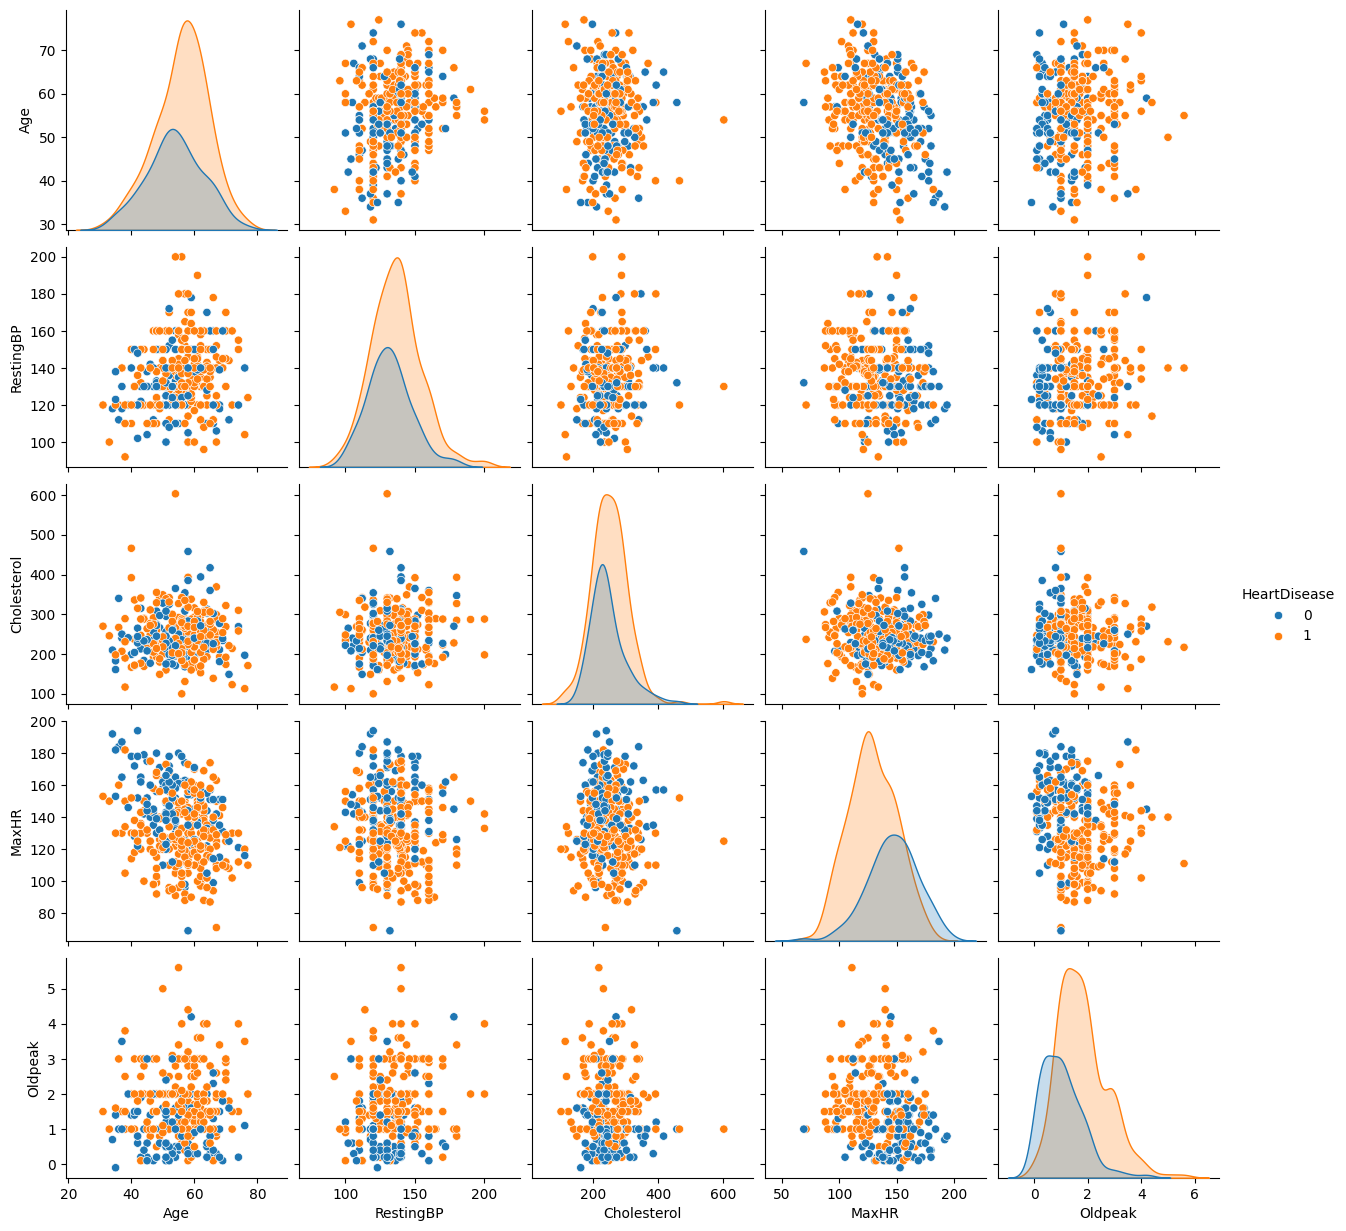

In [ ]:
sns.pairplot(pd.concat([Xtrn[num_cols], ytrn], axis=1), hue='HeartDisease')
plt.show()

## Distribución de variables


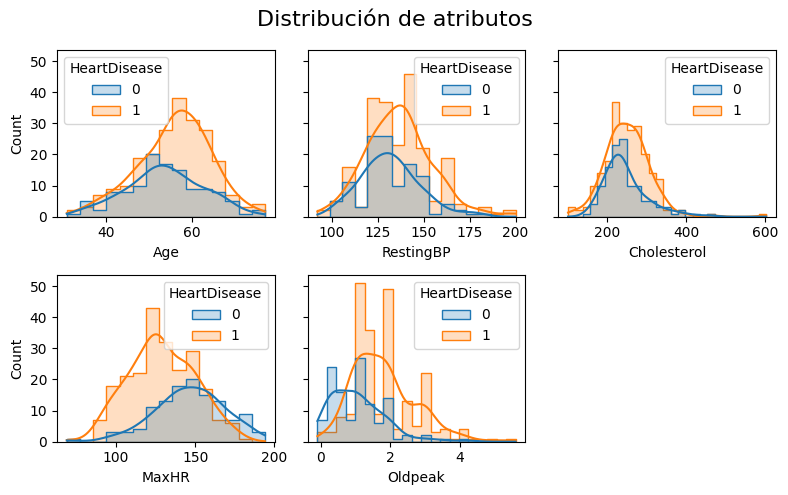

In [ ]:
r = 2
c = 3
fig, axes = plt.subplots(nrows=r, ncols=c, sharey=True,
                         figsize=(8, 5))
for i, col in enumerate(num_cols, 1):
    sns.histplot(data=pd.concat([Xtrn[num_cols], ytrn], axis=1), x=col,
                 hue='HeartDisease', kde=True, element='step',
                 ax=axes.flatten()[i-1])

for i in range(len(num_cols)+1, (r*c)+1):
    axes.flatten()[i-1].axis('off')

plt.suptitle('Distribución de atributos', fontsize=16)
plt.tight_layout()
plt.show()

# Preparación de los datos

## Escalado
Las SVM encuentran mejores fronteras cuando los datos están normalizados.

In [ ]:
scaler = StandardScaler().set_output(transform="pandas")
Xtrn_escalado = Xtrn.copy()
Xtst_escalado = Xtst.copy()
Xtrn_escalado[num_cols] = scaler.fit_transform(Xtrn[num_cols])
Xtst_escalado[num_cols] = scaler.transform(Xtst[num_cols])

## Codificación de atributos categóricos

In [ ]:
# Convertir columnas categóricas en numéricas
cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
cat_labels = [Xtrn[col].unique().tolist() for col in cat_cols]
enc = OrdinalEncoder(categories=cat_labels).set_output(transform="pandas")
enc.fit(Xtrn[cat_cols])
Xtrn_escalado[cat_cols] = enc.transform(Xtrn[cat_cols])
Xtst_escalado[cat_cols] = enc.transform(Xtst[cat_cols])
# Mostrar el DataFrame después de la transformación
Xtrn_escalado.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
914,1.471041,0.0,0.0,0.526908,-0.972563,1,0.0,0.263603,0.0,1.976334,0.0
490,1.932362,0.0,1.0,-0.847807,-0.603675,0,0.0,-1.448170,1.0,-0.576622,0.0
552,1.817032,0.0,1.0,0.526908,-0.480713,0,0.0,-1.184820,1.0,0.274363,0.0
486,-0.028251,0.0,2.0,-1.420605,-0.603675,1,1.0,1.975375,0.0,-1.214861,1.0
811,0.317740,1.0,0.0,-1.993403,-0.006429,0,2.0,-0.570338,0.0,-0.576622,0.0


In [ ]:
cat_labels

[['M', 'F'],
 ['ASY', 'NAP', 'ATA', 'TA'],
 ['Normal', 'ST', 'LVH'],
 ['N', 'Y'],
 ['Flat', 'Up', 'Down']]

# Definición de funciones

In [ ]:
def eval_svc(model, X, y):
  y_pred = model.predict(X)
  labels = ['baja', 'alta']
  disp = ConfusionMatrixDisplay.from_predictions(ytst, y_pred,
        display_labels=labels, cmap=plt.cm.Blues, colorbar=False)
  disp.ax_.set_title('Probabilidad de infarto de miocardio')
  disp.ax_.set_xlabel('Predicción')
  disp.ax_.set_ylabel('Real')
  plt.show()
  print("\n")
  print(classification_report(y, y_pred, target_names=labels))

def plot_svc_decision_function(model, X0, Y0, y0, features= ['0', '1']):
  """Graficar hiperplano de decisión en 2D"""
  x = np.linspace(np.min(X0), np.max(X0), 50)
  y = np.linspace(np.min(Y0), np.max(Y0), 50)
  Y, X = np.meshgrid(y, x)
  grid = np.vstack([X.ravel(), Y.ravel()]).T

  pred_grid = model.predict(grid)

  fig, ax = plt.subplots(figsize=(6,4))
  ax.scatter(grid[:,0], grid[:,1], c=pred_grid, alpha = 0.2)
  ax.scatter(X0, Y0, c = y0, alpha = 1)

  ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=200,
             linewidth=1, facecolors='none', edgecolors='black')

  ax.contour(X, Y, model.decision_function(grid).reshape(X.shape), colors = 'k',
             levels = [-1, 0, 1], alpha = 0.5, linestyles = ['--', '-', '--'])
  ax.set_xlabel(features[0])
  ax.set_ylabel(features[1])
  ax.set_title('Frontera de decisión')
  fig.show()

# SVM Lineal

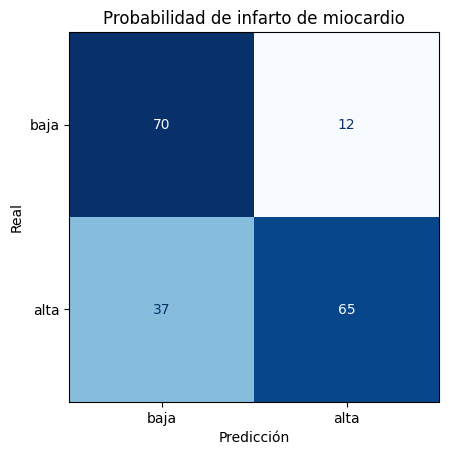



              precision    recall  f1-score   support

        baja       0.65      0.85      0.74        82
        alta       0.84      0.64      0.73       102

    accuracy                           0.73       184
   macro avg       0.75      0.75      0.73       184
weighted avg       0.76      0.73      0.73       184



In [ ]:
# Definición del Modelo
svm_classifier_linear = SVC(kernel='linear')

# Entrenamiento
svm_classifier_linear.fit(Xtrn_escalado[num_cols], ytrn)
eval_svc(svm_classifier_linear, Xtst_escalado[num_cols], ytst)

## Frontera de decisión
Elijo y visualizo las variables a clasificar.

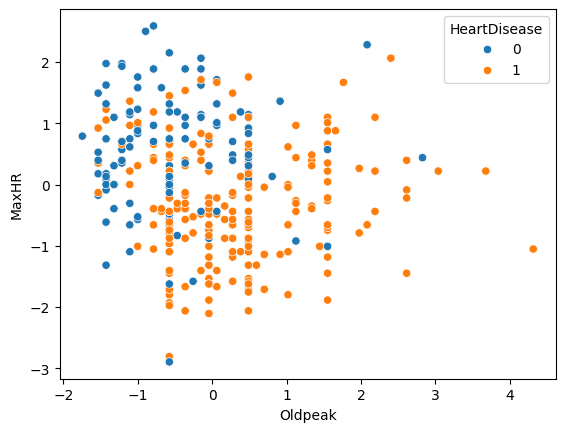

In [ ]:
bidim = ['Oldpeak', 'MaxHR']
sns.scatterplot(data=Xtrn_escalado[bidim], x=bidim[0], y=bidim[1], hue=ytrn)
plt.show()

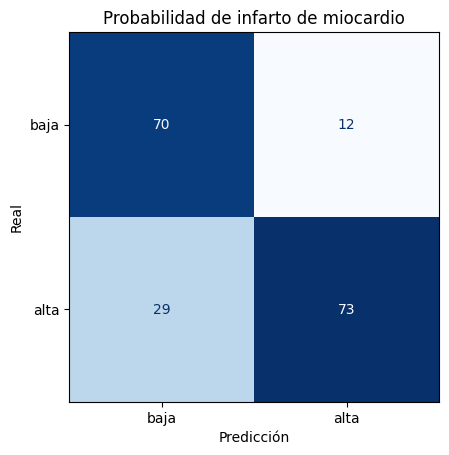



              precision    recall  f1-score   support

        baja       0.71      0.85      0.77        82
        alta       0.86      0.72      0.78       102

    accuracy                           0.78       184
   macro avg       0.78      0.78      0.78       184
weighted avg       0.79      0.78      0.78       184



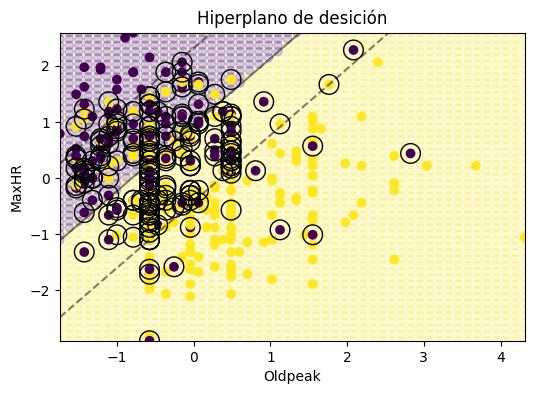

In [ ]:
svm_classifier_linear.fit(Xtrn_escalado[bidim], ytrn)
eval_svc(svm_classifier_linear, Xtst_escalado[bidim], ytst)
plot_svc_decision_function(svm_classifier_linear, Xtrn_escalado[bidim[0]],
                           Xtrn_escalado[bidim[1]], ytrn, bidim)

## Parámetro C

El parámetro `C` controla la penalización por errores de clasificación:
- **C pequeño**: permite más errores, márgenes más amplios.
- **C grande**: penaliza errores, márgenes más estrechos, mayor riesgo de sobreajuste.

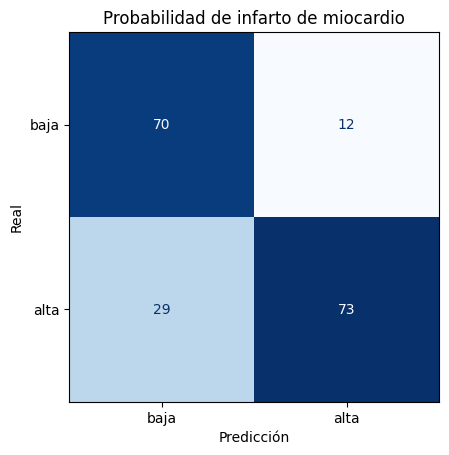



              precision    recall  f1-score   support

        baja       0.71      0.85      0.77        82
        alta       0.86      0.72      0.78       102

    accuracy                           0.78       184
   macro avg       0.78      0.78      0.78       184
weighted avg       0.79      0.78      0.78       184



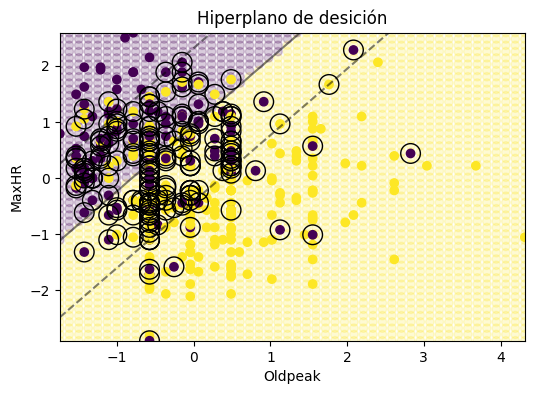

In [ ]:
svm_classifier_linear = SVC(kernel='linear', C=100)
svm_classifier_linear.fit(Xtrn_escalado[bidim], ytrn)
eval_svc(svm_classifier_linear, Xtst_escalado[bidim], ytst)
plot_svc_decision_function(svm_classifier_linear, Xtrn_escalado[bidim[0]],
                           Xtrn_escalado[bidim[1]], ytrn, bidim)

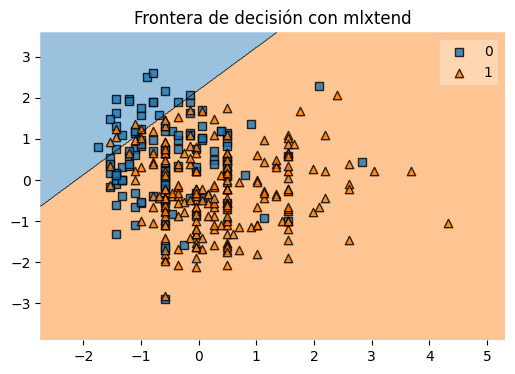

In [ ]:
from mlxtend.plotting import plot_decision_regions
fig, ax = plt.subplots(figsize=(6,4))
plot_decision_regions(
    X = Xtrn_escalado[bidim].to_numpy(),
    y = ytrn.to_numpy(),
    clf = svm_classifier_linear,
    ax = ax
)
ax.set_title("Frontera de decisión con mlxtend");

## Kernels

SVM puede usar diferentes funciones de kernel para transformar los datos.

En la [documentación](https://scikit-learn.org/stable/modules/svm.html#kernel-functions) pueden ver en detalle que hiperparámetro afecta a cada kernel y como [definir su propio kernel](https://scikit-learn.org/stable/auto_examples/svm/plot_custom_kernel.html)

### Polinomial
`poly`: kernel polinomial, transfrma los datos con una función polinómica.

Pueden variar el polinomio con `degree` y `coef0`.

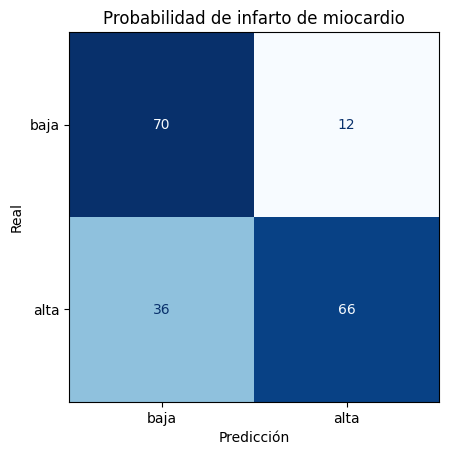



              precision    recall  f1-score   support

        baja       0.66      0.85      0.74        82
        alta       0.85      0.65      0.73       102

    accuracy                           0.74       184
   macro avg       0.75      0.75      0.74       184
weighted avg       0.76      0.74      0.74       184



In [ ]:
# Definición del Modelo
svm_classifier_poly = SVC(kernel='poly', C=0.1, degree=3, coef0=2)
# Entrenamiento y evaluación
svm_classifier_poly.fit(Xtrn_escalado[num_cols], ytrn)
eval_svc(svm_classifier_poly, Xtst_escalado[num_cols], ytst)

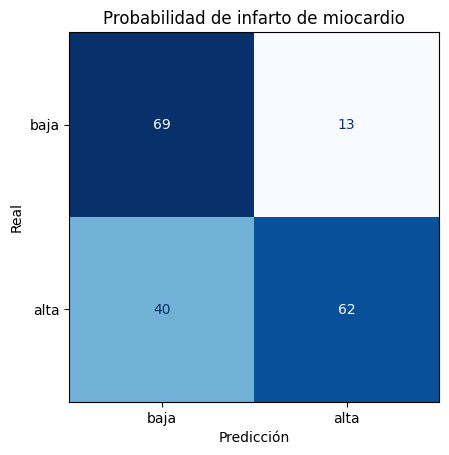



              precision    recall  f1-score   support

        baja       0.63      0.84      0.72        82
        alta       0.83      0.61      0.70       102

    accuracy                           0.71       184
   macro avg       0.73      0.72      0.71       184
weighted avg       0.74      0.71      0.71       184



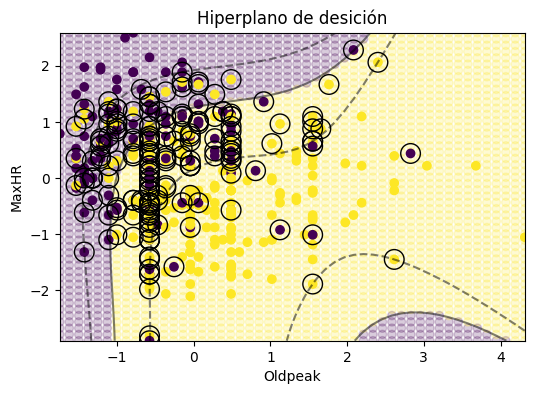

In [ ]:
svm_classifier_poly.fit(Xtrn_escalado[bidim], ytrn)
eval_svc(svm_classifier_poly, Xtst_escalado[bidim], ytst)
plot_svc_decision_function(svm_classifier_poly, Xtrn_escalado[bidim[0]],
                           Xtrn_escalado[bidim[1]], ytrn, bidim)

### Funcion de base radial (RBF) gaussiana

`rbf`: kernel radial, utiliza una función gaussiana para transformar los datos.

Se puede variar la campana con el hiperparámetro `gamma`.

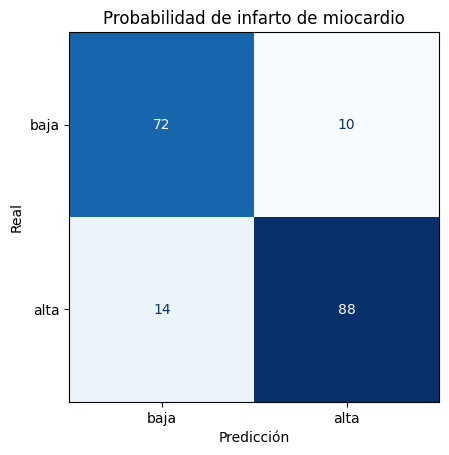



              precision    recall  f1-score   support

        baja       0.84      0.88      0.86        82
        alta       0.90      0.86      0.88       102

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184



In [ ]:
svm_classifier_rbf = SVC(kernel='rbf', C=1, gamma='scale')
svm_classifier_rbf.fit(Xtrn_escalado, ytrn)
eval_svc(svm_classifier_rbf, Xtst_escalado, ytst)

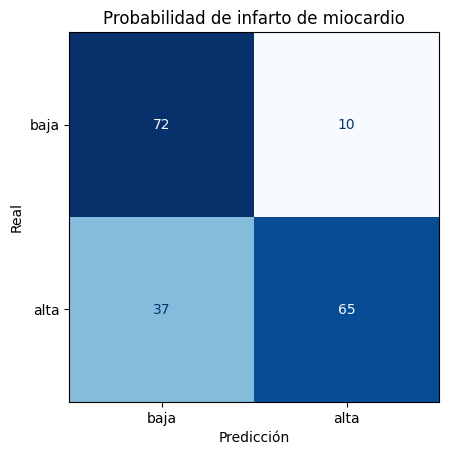



              precision    recall  f1-score   support

        baja       0.66      0.88      0.75        82
        alta       0.87      0.64      0.73       102

    accuracy                           0.74       184
   macro avg       0.76      0.76      0.74       184
weighted avg       0.77      0.74      0.74       184



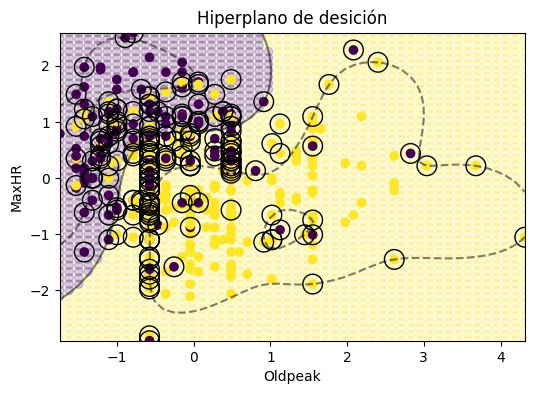

In [ ]:
svm_classifier_rbf.fit(Xtrn_escalado[bidim], ytrn)
eval_svc(svm_classifier_rbf, Xtst_escalado[bidim], ytst)
plot_svc_decision_function(svm_classifier_rbf, Xtrn_escalado[bidim[0]],
                           Xtrn_escalado[bidim[1]], ytrn, bidim)

### Sigmoideo

`sigmoid`: aplica una función sigmoidea a los datos.

Pueden variar la función con `gamma` y `coef0`.

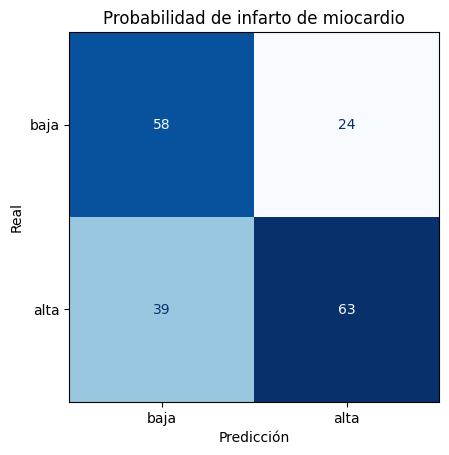



              precision    recall  f1-score   support

        baja       0.60      0.71      0.65        82
        alta       0.72      0.62      0.67       102

    accuracy                           0.66       184
   macro avg       0.66      0.66      0.66       184
weighted avg       0.67      0.66      0.66       184



In [ ]:
svm_classifier_sigmoid = SVC(kernel='sigmoid', C=1.0, gamma='scale', coef0=0.0)
svm_classifier_sigmoid.fit(Xtrn_escalado[bidim], ytrn)
eval_svc(svm_classifier_sigmoid, Xtst_escalado[bidim], ytst)

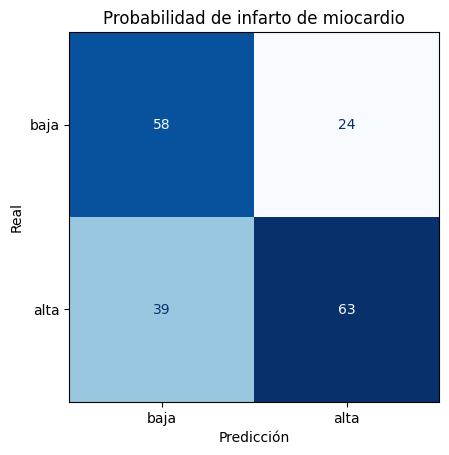



              precision    recall  f1-score   support

        baja       0.60      0.71      0.65        82
        alta       0.72      0.62      0.67       102

    accuracy                           0.66       184
   macro avg       0.66      0.66      0.66       184
weighted avg       0.67      0.66      0.66       184



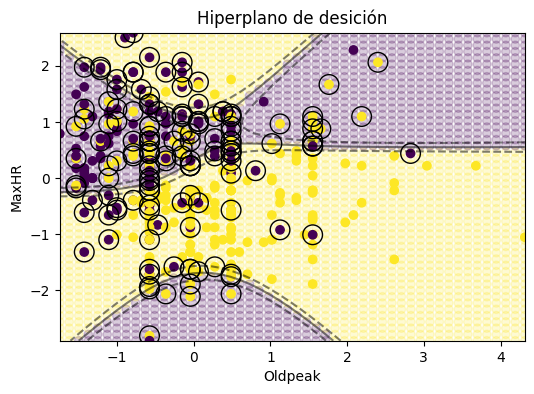

In [ ]:
svm_classifier_sigmoid.fit(Xtrn_escalado[bidim], ytrn)
eval_svc(svm_classifier_sigmoid, Xtst_escalado[bidim], ytst)
plot_svc_decision_function(svm_classifier_sigmoid, Xtrn_escalado[bidim[0]],
                           Xtrn_escalado[bidim[1]], ytrn, bidim)

# SVM Multiclase


**Acerca del conjunto de datos**

La base de datos de Reconocimiento de Actividad Humana se construyó a partir de grabaciones de 30 participantes que realizaban actividades de la vida diaria (AVD) mientras llevaban un teléfono inteligente montado en la cintura con sensores inerciales integrados.

El objetivo es clasificar cada una de las seis actividades realizadas.

**Descripción del experimento**

Los experimentos se han llevado a cabo con un grupo de 30 voluntarios de entre 19 y 48 años. Cada persona realizó seis actividades:

* ACOSTADO
* SENTADO
* DE PIE
* CAMINAR
* CAMINAR_ARRIBA
* CAMINAR_ABAJO

Llevando un teléfono inteligente (Samsung Galaxy S II) en la cintura. Usando su acelerómetro y giroscopio integrados, capturamos una aceleración lineal de 3 ejes y una velocidad angular de 3 ejes a una velocidad constante de 50 Hz. Los experimentos han sido grabados en vídeo para etiquetar los datos manualmente. El conjunto de datos obtenido se dividió aleatoriamente en dos conjuntos, donde se seleccionó el 70% de los voluntarios para generar los datos de entrenamiento y el 30% los datos de prueba.

Las señales de los sensores (acelerómetro y giroscopio) fueron preprocesadas aplicando filtros de ruido y luego muestreadas en ventanas deslizantes de ancho fijo de 2,56 segundos y 50% de superposición (128 lecturas/ventana). La señal de aceleración del sensor, que tiene componentes gravitacionales y de movimiento corporal, se separó mediante un filtro de paso bajo de Butterworth en aceleración corporal y gravedad. Se supone que la fuerza gravitacional tiene sólo componentes de baja frecuencia, por lo que se utilizó un filtro con una frecuencia de corte de 0,3 Hz. De cada ventana, se obtuvo un vector de características calculando variables del dominio del tiempo y la frecuencia.

**Información de atributos**

Para cada registro del conjunto de datos se proporciona lo siguiente:

* Aceleración triaxial del acelerómetro (aceleración total) y aceleración corporal estimada.
* Velocidad angular triaxial del giroscopio.
* Un vector de 561 características con variables en el dominio del tiempo y la frecuencia.
* Etiqueta de actividad.

Link dataset: https://www.kaggle.com/datasets/uciml/human-activity-recognition-with-smartphones/

In [ ]:
!gdown 1_QARiBYJXGzDfLp_dcwBuV6QWX3em2Rm
!gdown 10AjZU7jiLJ8a_hY5Z-v793a6r0vIygWf

Downloading...
From: https://drive.google.com/uc?id=1_QARiBYJXGzDfLp_dcwBuV6QWX3em2Rm
To: /content/PhonesTest.csv
100% 19.3M/19.3M [00:00<00:00, 84.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=10AjZU7jiLJ8a_hY5Z-v793a6r0vIygWf
To: /content/PhonesTrain.csv
100% 48.1M/48.1M [00:00<00:00, 190MB/s]


In [ ]:
train = pd.read_csv("PhonesTrain.csv")
test = pd.read_csv("PhonesTest.csv")

## Estructura de los datos

In [ ]:
train.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [ ]:
print('Datos de entrenamiento: ', train.shape)
print('Datos de prueba: ', test.shape)

Datos de entrenamiento:  (7352, 563)
Datos de prueba:  (2947, 563)


In [ ]:
print("Valores faltantes en datos de entrenamiento:",train.isnull().values.any())
print("Valores faltantes en datos de prueba:",test.isnull().values.any(), "\n")

Valores faltantes en datos de entrenamiento: False
Valores faltantes en datos de prueba: False 



In [ ]:
# Distribución de las Clases
train['Activity'].value_counts()

,count
Activity,
LAYING,1407
STANDING,1374
SITTING,1286
WALKING,1226
WALKING_UPSTAIRS,1073
WALKING_DOWNSTAIRS,986


In [ ]:
# Separación de los datos de entrenamiento y variable objetivo
Xtrn = train.drop(['Activity','subject'],axis=1)
ytrn_label = train.Activity
Xtst = test.drop(['Activity','subject'],axis=1)
ytst_label = test.Activity
features = list(Xtrn.columns.values)

## Preparación de los datos

In [ ]:
# Transformar las clases en números
encoder = LabelEncoder()
# Entrenaamiento
encoder.fit(ytrn_label)
ytrn = encoder.transform(ytrn_label)
# Testeo
ytst = encoder.transform(ytst_label)

In [ ]:
# Estandarización
scaler = StandardScaler()
Xtrn = scaler.fit_transform(Xtrn)
Xtst = scaler.transform(Xtst)

## Optimización del modelo

In [ ]:
# Hiperparámetros de búsqueda
params_grid = [{'kernel': ['rbf'], 'gamma': [1e-3, 1e-4],
                'C': [1, 10, 100, 1000]},
                 {'kernel': ['linear'], 'C': [1, 10, 100, 1000]}]

In [ ]:
# Aplicar la búsqueda de grilla para elegir los mejores hiperparámetros
svm_model = GridSearchCV(SVC(), params_grid, cv=5)
svm_model.fit(Xtrn, ytrn)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid=[{'C': [1, 10, 100, 1000], 'gamma': [0.001, 0.0001],
                          'kernel': ['rbf']},
                         {'C': [1, 10, 100, 1000], 'kernel': ['linear']}])

In [ ]:
# Mejor modelo
print('C:',svm_model.best_estimator_.C,"\n")
print('Kernel:',svm_model.best_estimator_.kernel,"\n")
print('Gamma:',svm_model.best_estimator_.gamma,"\n")
print('Score:', svm_model.best_score_,"\n")

C: 1000 

Kernel: rbf 

Gamma: 0.0001 

Score: 0.938255432696532 



In [ ]:
from sklearn.model_selection import ValidationCurveDisplay, validation_curve
param_name, param_range = "C", np.logspace(-2, 10, 13)
train_scores, test_scores = validation_curve(svm_model.best_estimator_,Xtrn,
                                             ytrn, param_name=param_name,
                                             param_range=param_range)


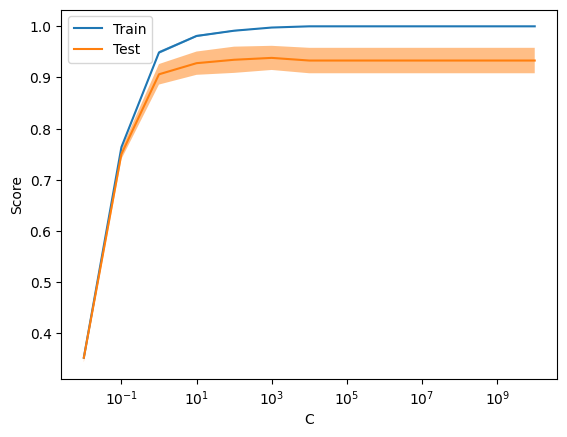

In [ ]:
display = ValidationCurveDisplay(param_name=param_name, param_range=param_range,
    train_scores=train_scores, test_scores=test_scores, score_name="Score")
display.plot()

## Entrenamiento y evaluación

In [ ]:
# Predicciones
final_model = svm_model.best_estimator_
y_pred = final_model.predict(Xtst)
y_pred_labels = list(encoder.inverse_transform(y_pred))
labels = list(encoder.classes_)

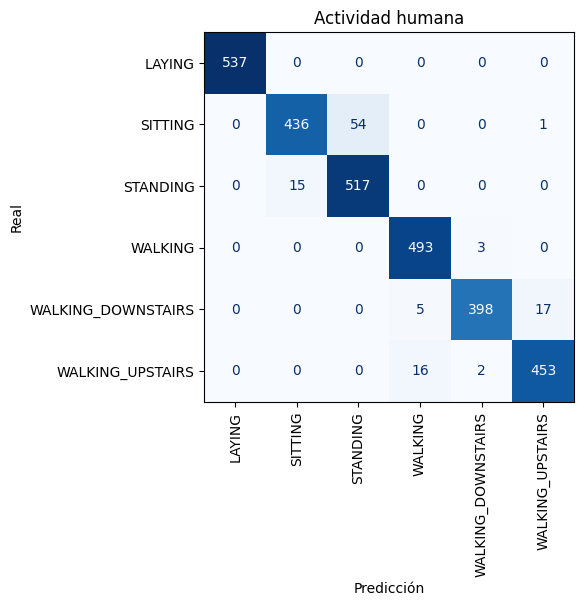



                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.97      0.89      0.93       491
          STANDING       0.91      0.97      0.94       532
           WALKING       0.96      0.99      0.98       496
WALKING_DOWNSTAIRS       0.99      0.95      0.97       420
  WALKING_UPSTAIRS       0.96      0.96      0.96       471

          accuracy                           0.96      2947
         macro avg       0.96      0.96      0.96      2947
      weighted avg       0.96      0.96      0.96      2947

Training set score for SVM: 0.996872
Testing  set score for SVM: 0.961656


In [ ]:
# Matriz de Confusión
disp = ConfusionMatrixDisplay.from_predictions(ytst, y_pred, xticks_rotation='vertical',
        display_labels=labels, cmap=plt.cm.Blues, colorbar=False)
disp.ax_.set_title('Actividad humana')
disp.ax_.set_xlabel('Predicción')
disp.ax_.set_ylabel('Real')
plt.show()
print("\n")
print(classification_report(ytst, y_pred, target_names=labels))
print("Training set score for SVM: %f" % final_model.score(Xtrn , ytrn))
print("Testing  set score for SVM: %f" % final_model.score(Xtst  , ytst ))